In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

 #If loading from Excel
df = pd.read_excel("Datasets.xlsx", sheet_name="Bakery sales")

# Convert date and time properly
df['date'] = pd.to_datetime(df['date'])
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S')

# Extract useful features
df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['date'].dt.day_name()

# Create revenue column
df['revenue'] = df['Quantity'] * df['unit_price']


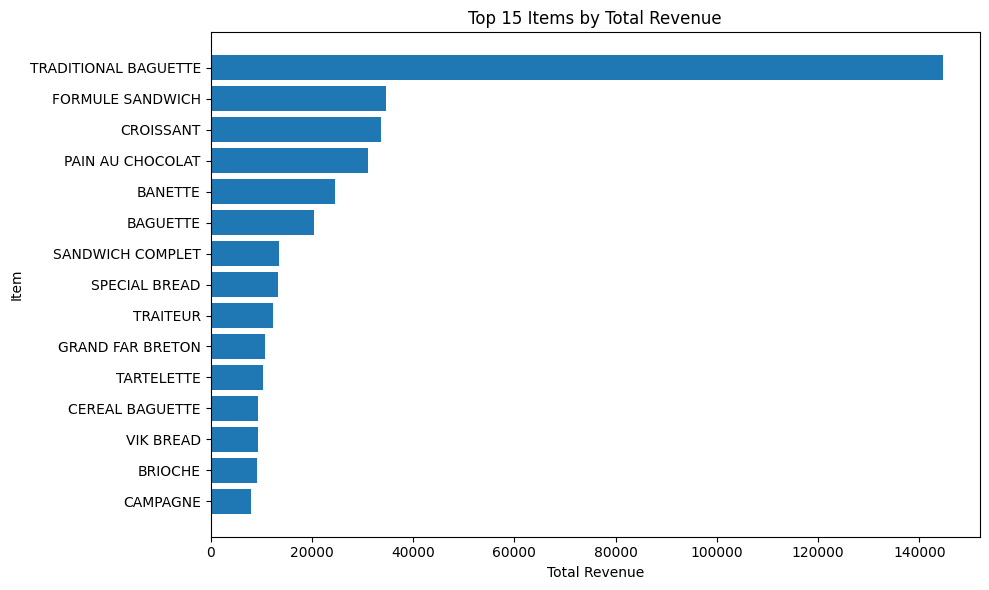

In [32]:
import matplotlib.pyplot as plt

top_n = 15
item_revenue = (df.groupby('item')['revenue']
                  .sum()
                  .sort_values(ascending=False)
                  .head(top_n)
                  .sort_values())  # sort for nice bottom->top order

plt.figure(figsize=(10, 6))
plt.barh(item_revenue.index, item_revenue.values)
plt.title(f"Top {top_n} Items by Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Item")
plt.tight_layout()
plt.show()



We can see that the traditional baguettes are the most popular item sold.

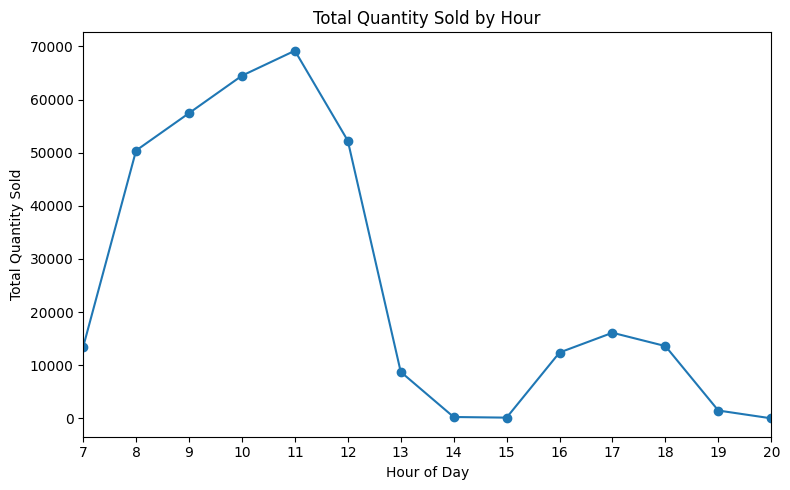

In [33]:
# Aggregate quantity by hour
hourly_sales = df.groupby('hour')['Quantity'].sum().sort_index()

# Get actual opening and closing hour from data
open_hour = hourly_sales.index.min()
close_hour = hourly_sales.index.max()

plt.figure(figsize=(8,5))
hourly_sales.plot(marker='o')

plt.title("Total Quantity Sold by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Total Quantity Sold")

# Only show hours bakery is open
plt.xticks(range(open_hour, close_hour + 1))
plt.xlim(open_hour, close_hour)

plt.tight_layout()
plt.show()



We can see that items sold peak during the afternoon and are sold more in the morning compared to evening

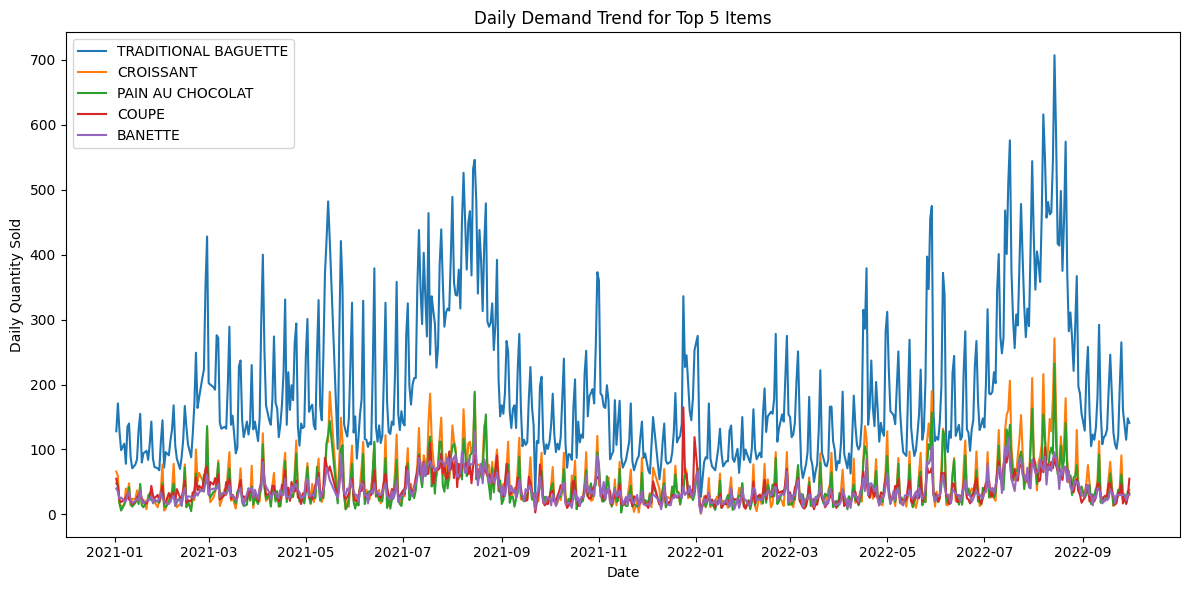

In [34]:
# Remove negative quantities (returns)
df_clean = df[df['Quantity'] > 0].copy()

# Daily aggregation
daily = df_clean.groupby(['date','item'])['Quantity'].sum().reset_index()

# Get top 5 items by total quantity
top_items = (daily.groupby('item')['Quantity']
                   .sum()
                   .sort_values(ascending=False)
                   .head(5)
                   .index)

plt.figure(figsize=(12,6))

for item in top_items:
    subset = daily[daily['item'] == item]
    plt.plot(subset['date'], subset['Quantity'], label=item)

plt.title("Daily Demand Trend for Top 5 Items")
plt.xlabel("Date")
plt.ylabel("Daily Quantity Sold")
plt.legend()
plt.tight_layout()
plt.show()



Traditional Baguette consistently sells the most, and demand for all items appears to rise around mid-year (summer months) and again later in the year, with noticeable spikes during those periods compared to earlier months.

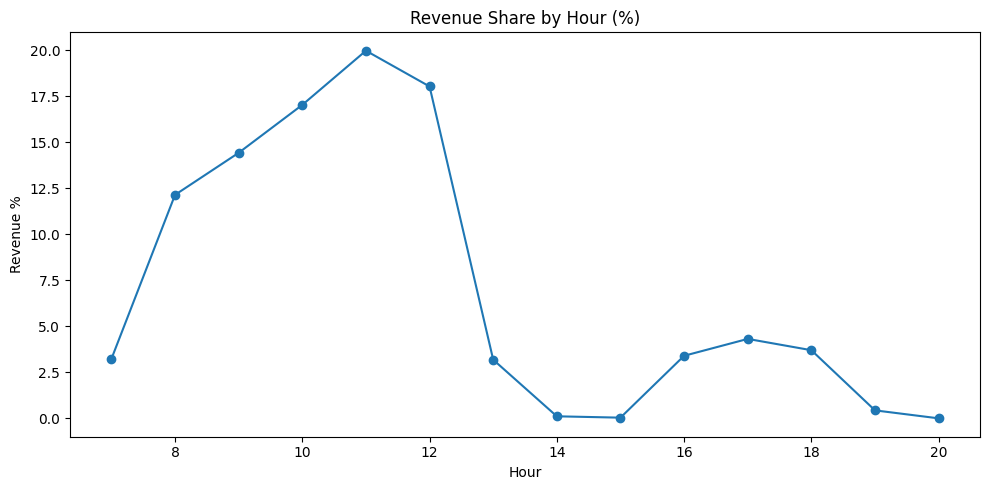

In [35]:
hour_rev = df.groupby('hour')['revenue'].sum()
hour_pct = hour_rev / hour_rev.sum() * 100

plt.figure(figsize=(10,5))
hour_pct.plot(marker='o')
plt.title("Revenue Share by Hour (%)")
plt.xlabel("Hour")
plt.ylabel("Revenue %")
plt.tight_layout()
plt.show()


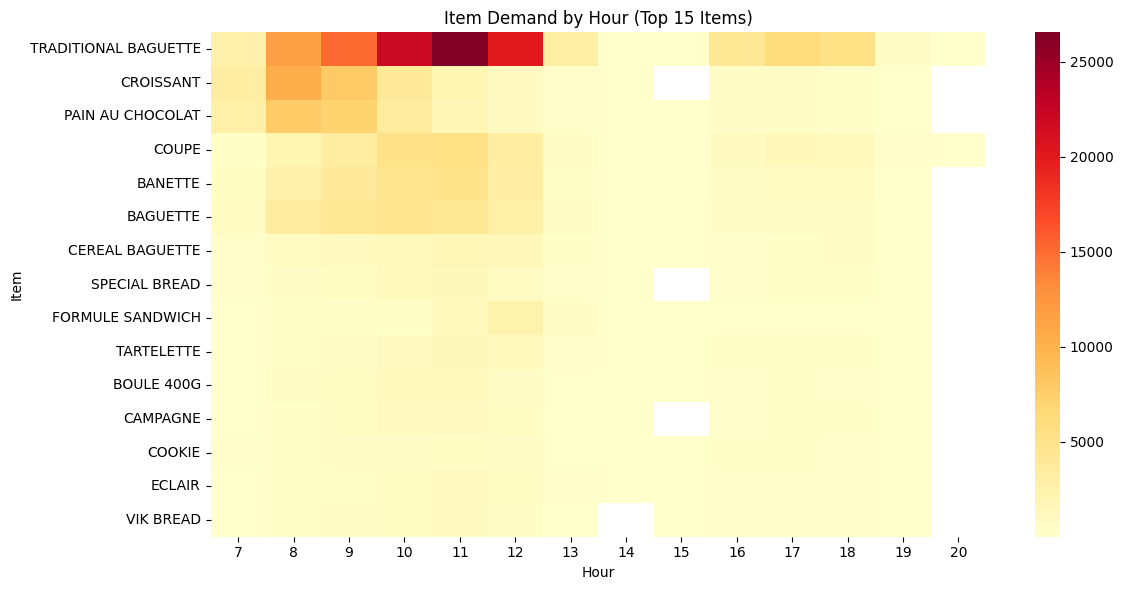

In [36]:
pivot = df.pivot_table(values='Quantity',
                       index='item',
                       columns='hour',
                       aggfunc='sum')

# Limit to top 15 items by total demand
top15 = df.groupby('item')['Quantity'].sum().sort_values(ascending=False).head(15).index
pivot = pivot.loc[top15]

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='YlOrRd')
plt.title("Item Demand by Hour (Top 15 Items)")
plt.xlabel("Hour")
plt.ylabel("Item")
plt.tight_layout()
plt.show()


From the heatmap, demand clearly peaks between 9AM and 11AM, with the strongest intensity around 10–11AM, especially for Traditional Baguette and other core bread and pastry items. This indicates that mid-morning is the highest sales window of the day, meaning prices should remain stable (or even slightly higher) during this period since demand is naturally strong and discounting is unnecessary.

In [37]:
category_map = {
    # Breads
    'TRADITIONAL BAGUETTE': 'Bread',
    'BAGUETTE': 'Bread',
    'BANETTE': 'Bread',
    'CEREAL BAGUETTE': 'Bread',
    'SPECIAL BREAD': 'Bread',
    'VIK BREAD': 'Bread',
    'CAMPAGNE': 'Bread',

    # Pastries / Viennoiserie
    'CROISSANT': 'Pastry',
    'PAIN AU CHOCOLAT': 'Pastry',
    'BRIOCHE': 'Pastry',

    # Sandwich / Savory
    'FORMULE SANDWICH': 'Sandwich',
    'SANDWICH COMPLET': 'Sandwich',
    'TRAITEUR': 'Savory',

    # Dessert
    'GRAND FAR BRETON': 'Dessert',
    'TARTELETTE': 'Dessert'
}


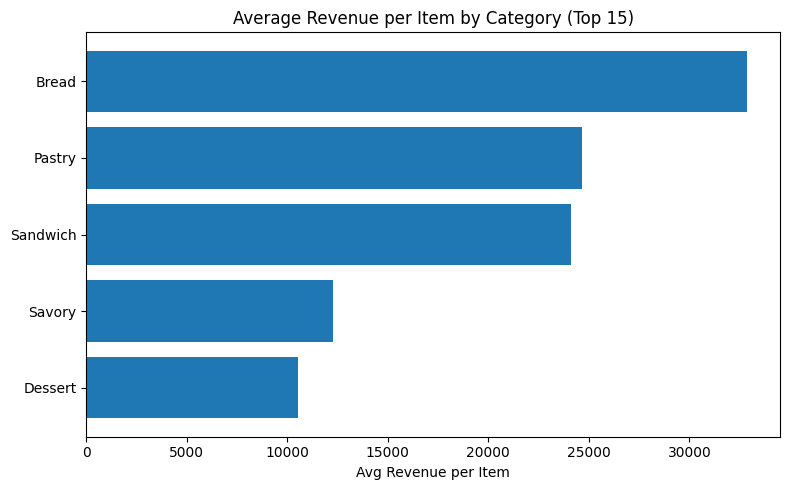

In [38]:
cat_avg = (df_top15.groupby(['category','item'])['revenue']
                    .sum()
                    .groupby('category')
                    .mean()
                    .sort_values(ascending=False))

plt.figure(figsize=(8,5))
plt.barh(cat_avg.index, cat_avg.values)
plt.title("Average Revenue per Item by Category (Top 15)")
plt.xlabel("Avg Revenue per Item")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


On average, the bread category contributes to the most revenue

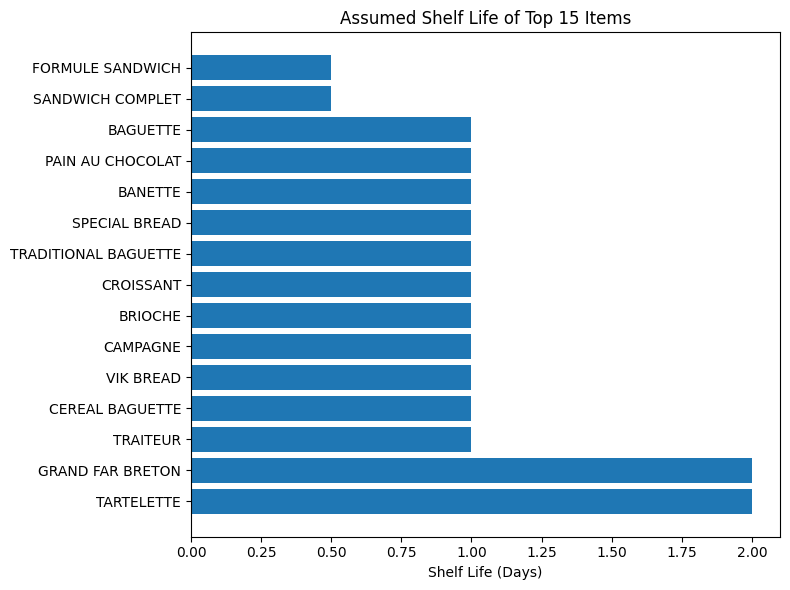

In [39]:
# First make sure categories are mapped (using your earlier category_map)

df_top15['shelf_life_days'] = df_top15['category'].map({
    'Bread': 1,
    'Pastry': 1,
    'Sandwich': 0.5,   # <1 day
    'Dessert': 2,
    'Savory': 1
})
shelf_df = df_top15[['item','category','shelf_life_days']].drop_duplicates()

# Sort by shelf life
shelf_df = shelf_df.sort_values('shelf_life_days')
plt.figure(figsize=(8,6))
plt.barh(shelf_df['item'], shelf_df['shelf_life_days'])

plt.title("Assumed Shelf Life of Top 15 Items")
plt.xlabel("Shelf Life (Days)")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


The visualization shows the percentage of revenue generated after 3PM for items grouped by their assumed shelf life. Items with very short shelf life (0.5 day, such as sandwiches) generate almost no revenue late in the day, indicating that most of their sales occur earlier and demand drops sharply in the afternoon. Items with a one-day shelf life (bread and pastries) show moderate late-day revenue, while items with a longer shelf life (2 days, such as desserts) have a higher proportion of late-day sales. This suggests that shorter shelf-life products are more vulnerable to end-of-day waste because demand declines well before expiration, making them strong candidates for time-based markdown pricing to reduce unsold inventory.

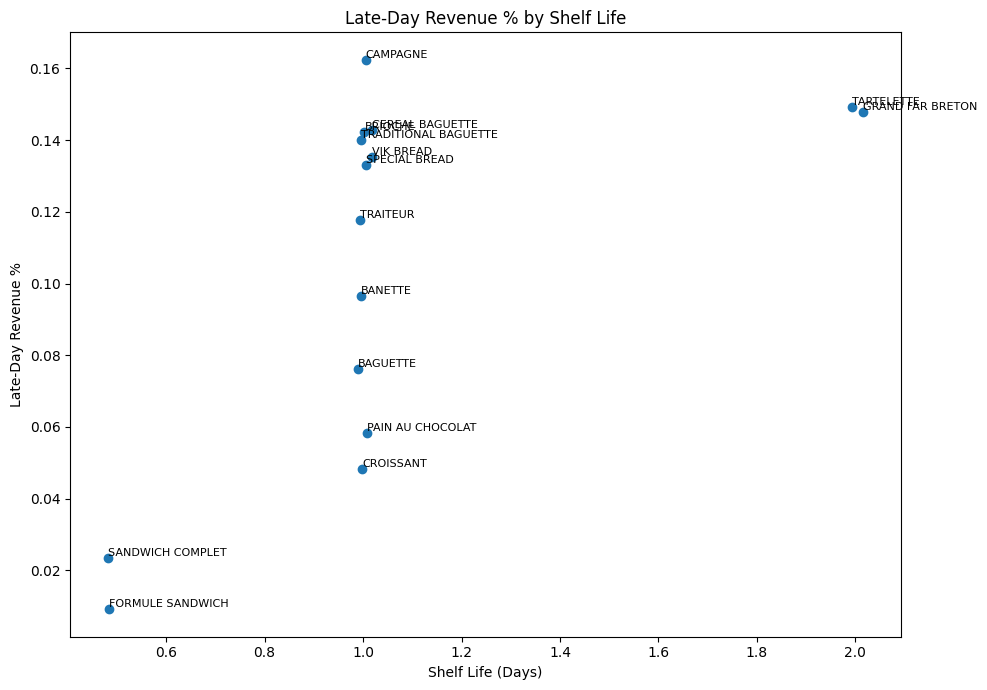

In [40]:
plt.figure(figsize=(10,7))

# Add small jitter so points don't stack exactly
import numpy as np
x_jitter = late_df['shelf_life_days'] + np.random.uniform(-0.02, 0.02, size=len(late_df))

plt.scatter(x_jitter, late_df['late_pct'])

# Add labels
for i in range(len(late_df)):
    plt.text(x_jitter.iloc[i],
             late_df['late_pct'].iloc[i],
             late_df['item'].iloc[i],
             fontsize=8,
             verticalalignment='bottom')

plt.title("Late-Day Revenue % by Shelf Life")
plt.xlabel("Shelf Life (Days)")
plt.ylabel("Late-Day Revenue %")

plt.tight_layout()
plt.show()


🥪 1️⃣ Sandwiches (0.5 Day Shelf Life – Highest Waste Risk)

Problem:
Almost all sales happen early. Very little demand after 3PM.

Suggestion:

Introduce graduated markdown pricing in the afternoon.

Example:

3PM → 10% discount

4:30PM → 20% discount

5:30PM → 30% discount

This helps clear inventory before expiration.

🥖 2️⃣ Bread & Pastry (1-Day Shelf Life – Moderate Risk)

Problem:
Some late-day sales, but still demand concentration earlier.

Suggestion:

Light discount toward closing time.

Example:

1–2 hours before closing → 10–15% discount.

Or bundle pricing (e.g., “Buy 2 pastries, get 1 at 50% off”).

This reduces leftover inventory without hurting daytime revenue.

🍰 3️⃣ Desserts (2-Day Shelf Life – Lower Risk)

Problem:
Sales are more evenly distributed.

Suggestion:

No aggressive markdown needed.

Consider small discounts only if inventory is high.

Focus pricing strategy more on demand elasticity than waste.

🎯 General Waste-Reduction Pricing Framework

Instead of static pricing:

Keep regular pricing during peak hours.

Apply markdowns when demand drops.

Only target short shelf-life items.

Avoid discounting high-demand peak periods.

📌 Key Strategic Insight

Dynamic pricing for waste reduction should be:

Time-sensitive

Shelf-life-sensitive

Category-specific

Not all products need price changes — only those at risk of expiring unsold.